# 🏗️ Prediksi Kuat Tekan Beton — Machine Learning Regression
---
**Tujuan:** Memprediksi nilai **Concrete Compressive Strength (MPa)** dari 8 variabel input material beton menggunakan algoritma Machine Learning.

| Variabel Input | Satuan |
|---|---|
| Cement | kg/m³ |
| Blast Furnace Slag | kg/m³ |
| Fly Ash | kg/m³ |
| Water | kg/m³ |
| Superplasticizer | kg/m³ |
| Coarse Aggregate | kg/m³ |
| Fine Aggregate | kg/m³ |
| Age | hari |

**Target:** `Concrete Compressive Strength (MPa)`


## 1. Import Library

In [4]:
# ── Manipulasi Data ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Preprocessing & Model Selection ──────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Model Regresi ─────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ── Konfigurasi Tampilan ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("✅ Semua library berhasil diimport.")


ModuleNotFoundError: No module named 'xgboost'

## 2. Load & Eksplorasi Dataset

In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
df = pd.read_excel('Concrete_Data.xlsx')

# ── Sederhanakan nama kolom ──────────────────────────────────────────────────
df.columns = [
    'Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water',
    'Superplasticizer', 'CoarseAggregate', 'FineAggregate',
    'Age', 'CompressiveStrength'
]

print(f"📐 Ukuran dataset: {df.shape[0]} baris × {df.shape[1]} kolom\n")
df.head(10)


📐 Ukuran dataset: 1030 baris × 9 kolom



,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.029847
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.698299
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.447770
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.854291
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.289790


In [3]:
# ── Info tipe data & non-null ─────────────────────────────────────────────────
print("=" * 50)
print("INFO DATASET")
print("=" * 50)
df.info()


INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cement               1030 non-null   float64
 1   BlastFurnaceSlag     1030 non-null   float64
 2   FlyAsh               1030 non-null   float64
 3   Water                1030 non-null   float64
 4   Superplasticizer     1030 non-null   float64
 5   CoarseAggregate      1030 non-null   float64
 6   FineAggregate        1030 non-null   float64
 7   Age                  1030 non-null   int64  
 8   CompressiveStrength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [4]:
# ── Statistik Deskriptif ──────────────────────────────────────────────────────
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
df.describe().round(2)


STATISTIK DESKRIPTIF


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.36,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.75,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.35,968.00,779.51,28.00,34.44
75%,350.00,142.95,118.27,192.00,10.16,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


In [5]:
# ── Cek Missing Values ────────────────────────────────────────────────────────
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': pct})

print("=" * 40)
print("CEK MISSING VALUES")
print("=" * 40)
if missing.sum() == 0:
    print("✅ Tidak ada missing values — dataset bersih!")
else:
    print(missing_df[missing_df['Jumlah Missing'] > 0])

print(f"\nTotal duplikat: {df.duplicated().sum()} baris")


CEK MISSING VALUES
✅ Tidak ada missing values — dataset bersih!

Total duplikat: 25 baris


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Setiap Variabel

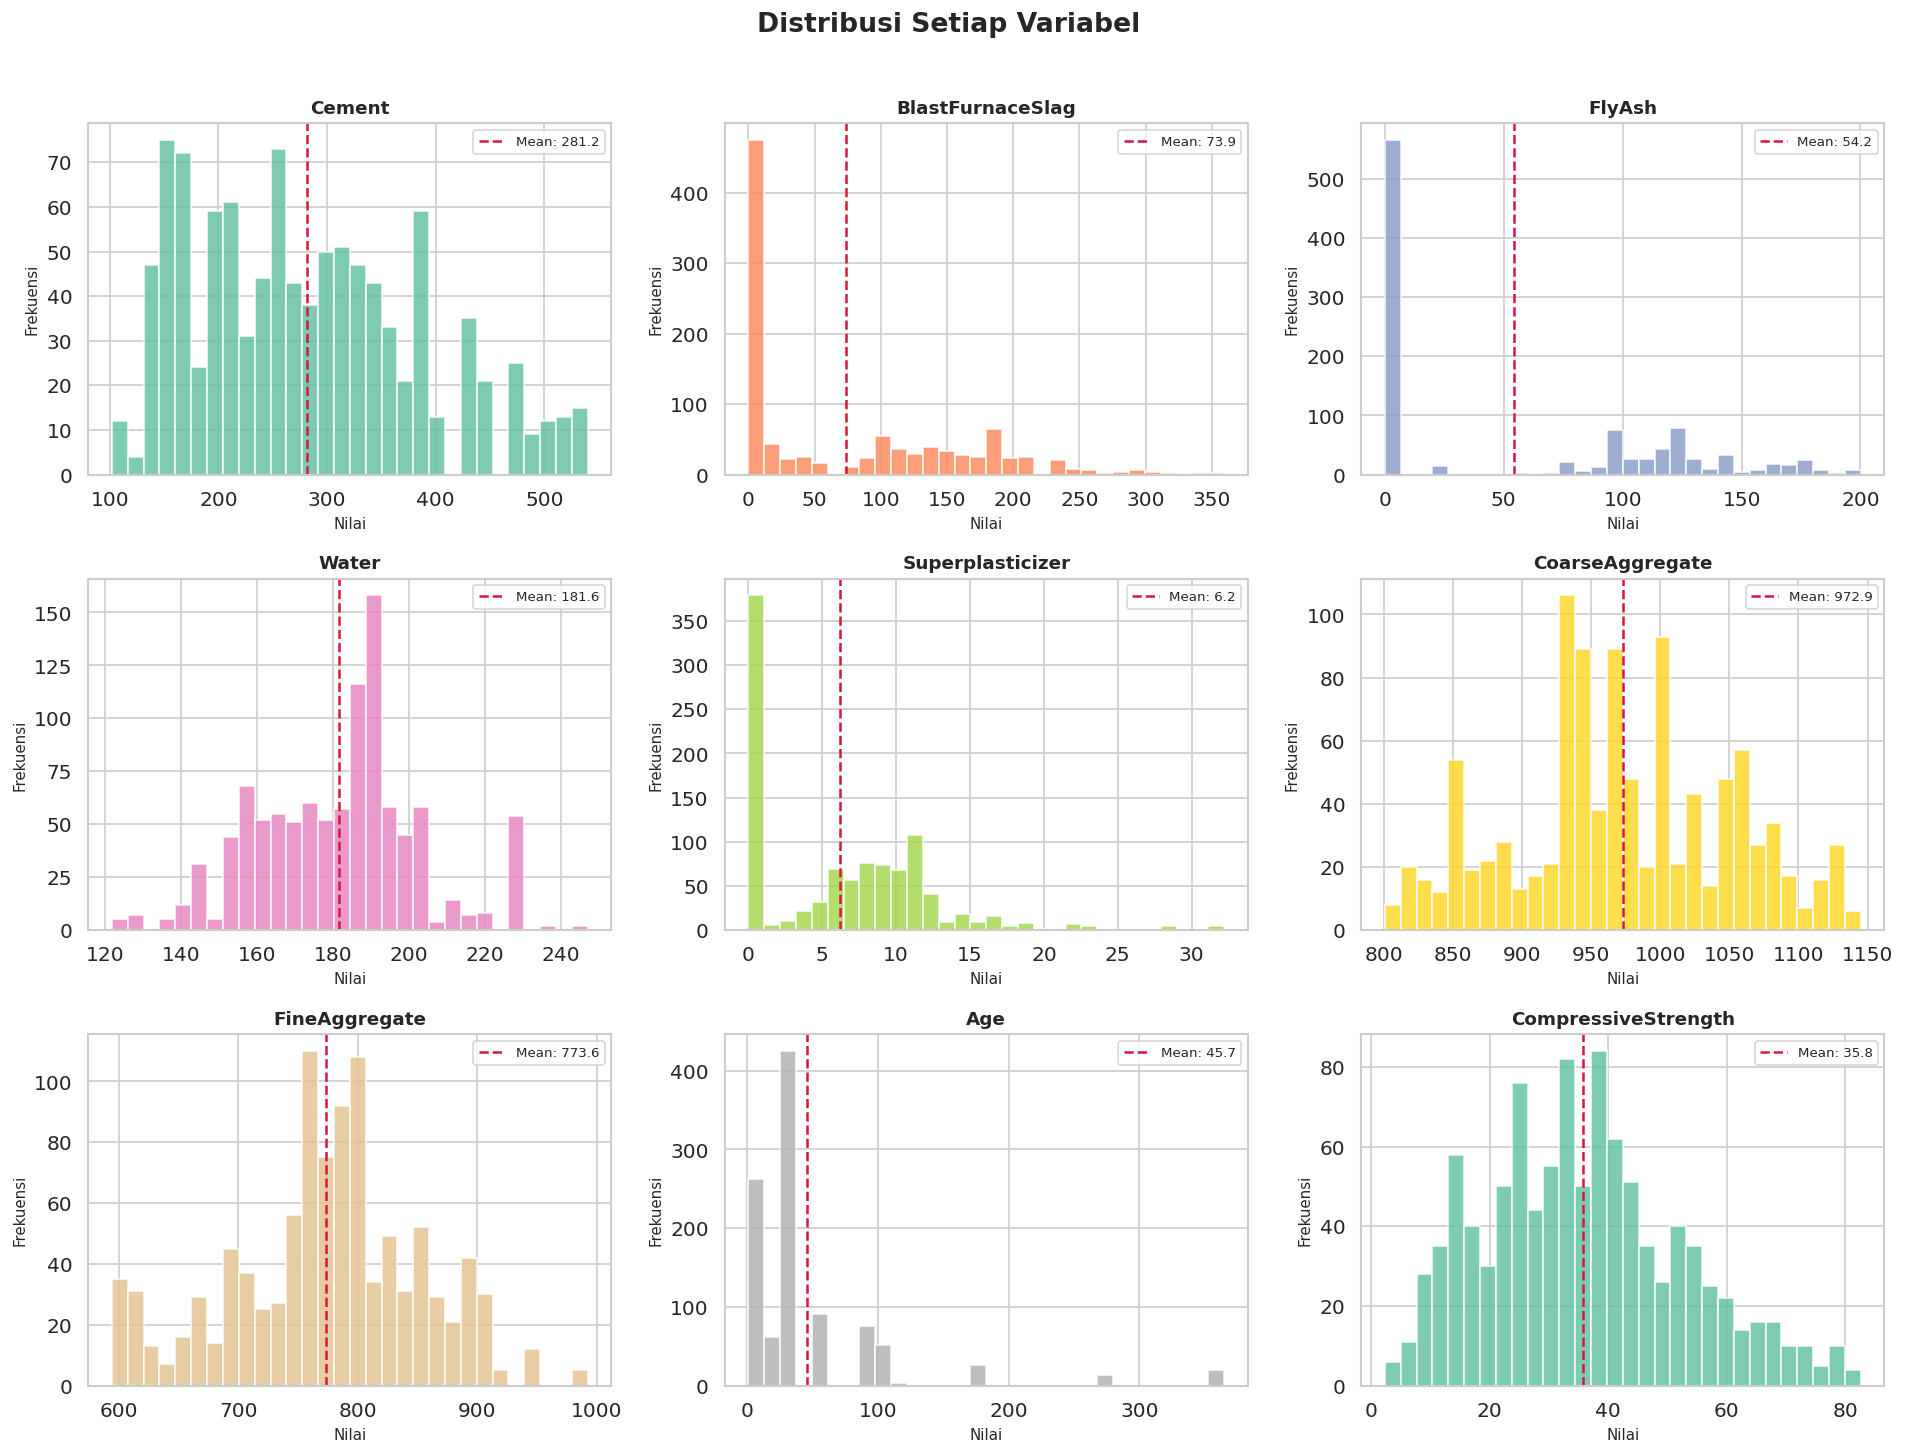


📊 Interpretasi Distribusi:
• Cement        : Right-skewed; sebagian besar campuran menggunakan 150–350 kg/m³
• BlastFurnaceSlag : Banyak nilai 0, artinya tidak semua campuran menggunakannya
• FlyAsh        : Serupa dengan Slag, banyak yang 0 (tidak wajib digunakan)
• Water         : Distribusi mendekati normal, berkisar 150–230 kg/m³
• Superplasticizer: Banyak nilai 0; umumnya hanya ditambahkan pada campuran tertentu
• CoarseAggregate: Distribusi relatif merata (uniform)
• FineAggregate : Distribusi mendekati normal
• Age           : Sangat right-skewed; mayoritas sampel diuji pada umur muda (≤28 hari)
• CompressiveStrength: Right-skewed; kuat tekan mayoritas di kisaran 20–55 MPa



In [6]:
# ── Histogram semua variabel ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

colors = sns.color_palette('Set2', 9)

for i, col in enumerate(df.columns):
    ax = axes[i]
    ax.hist(df[col], bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai', fontsize=9)
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.axvline(df[col].mean(), color='crimson', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Setiap Variabel', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hist_distribusi.png', bbox_inches='tight')
plt.show()

print("""
📊 Interpretasi Distribusi:
• Cement        : Right-skewed; sebagian besar campuran menggunakan 150–350 kg/m³
• BlastFurnaceSlag : Banyak nilai 0, artinya tidak semua campuran menggunakannya
• FlyAsh        : Serupa dengan Slag, banyak yang 0 (tidak wajib digunakan)
• Water         : Distribusi mendekati normal, berkisar 150–230 kg/m³
• Superplasticizer: Banyak nilai 0; umumnya hanya ditambahkan pada campuran tertentu
• CoarseAggregate: Distribusi relatif merata (uniform)
• FineAggregate : Distribusi mendekati normal
• Age           : Sangat right-skewed; mayoritas sampel diuji pada umur muda (≤28 hari)
• CompressiveStrength: Right-skewed; kuat tekan mayoritas di kisaran 20–55 MPa
""")


### 3.2 Correlation Heatmap

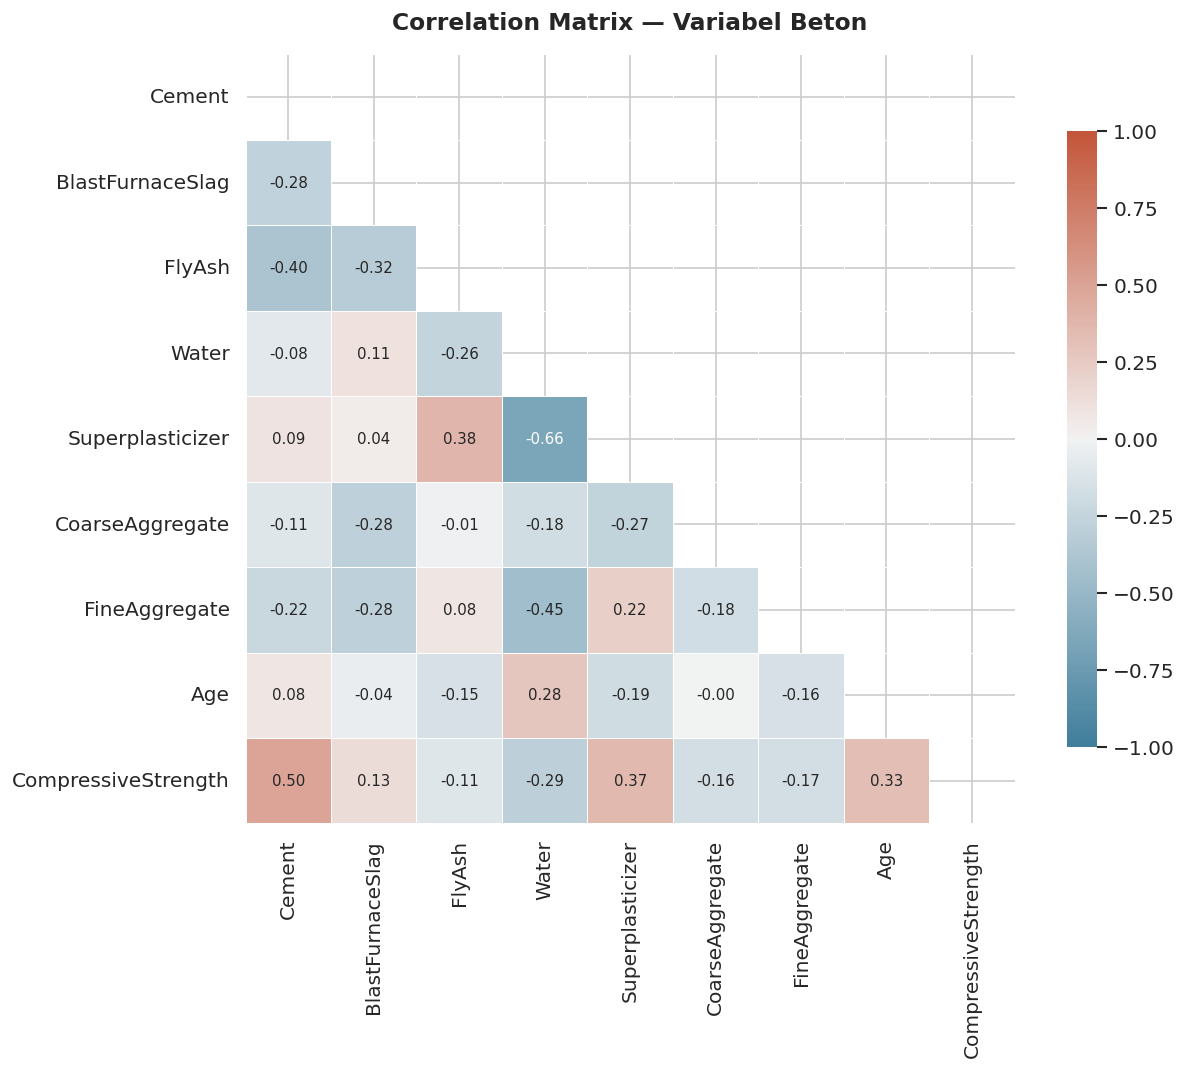

Korelasi terhadap CompressiveStrength:
Cement              0.497833
Superplasticizer    0.366102
Age                 0.328877
BlastFurnaceSlag    0.134824
FlyAsh             -0.105753
CoarseAggregate    -0.164928
FineAggregate      -0.167249
Water              -0.289613

📊 Interpretasi Korelasi:
• Age (+0.33) dan Cement (+0.50) memiliki korelasi POSITIF terkuat dengan kuat tekan
• Water (-0.29) berkorelasi NEGATIF — semakin banyak air, kuat tekan cenderung turun
• Superplasticizer (+0.37) berkorelasi positif moderat
• Aggregate (Coarse & Fine) hampir tidak berkorelasi dengan kuat tekan



In [7]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
corr = df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax, square=True,
    cbar_kws={'shrink': .8}
)
ax.set_title('Correlation Matrix — Variabel Beton', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', bbox_inches='tight')
plt.show()

# Cetak korelasi terhadap target
target_corr = corr['CompressiveStrength'].drop('CompressiveStrength').sort_values(ascending=False)
print("Korelasi terhadap CompressiveStrength:")
print(target_corr.to_string())
print("""
📊 Interpretasi Korelasi:
• Age (+0.33) dan Cement (+0.50) memiliki korelasi POSITIF terkuat dengan kuat tekan
• Water (-0.29) berkorelasi NEGATIF — semakin banyak air, kuat tekan cenderung turun
• Superplasticizer (+0.37) berkorelasi positif moderat
• Aggregate (Coarse & Fine) hampir tidak berkorelasi dengan kuat tekan
""")


### 3.3 Scatter Plot: Fitur vs Target

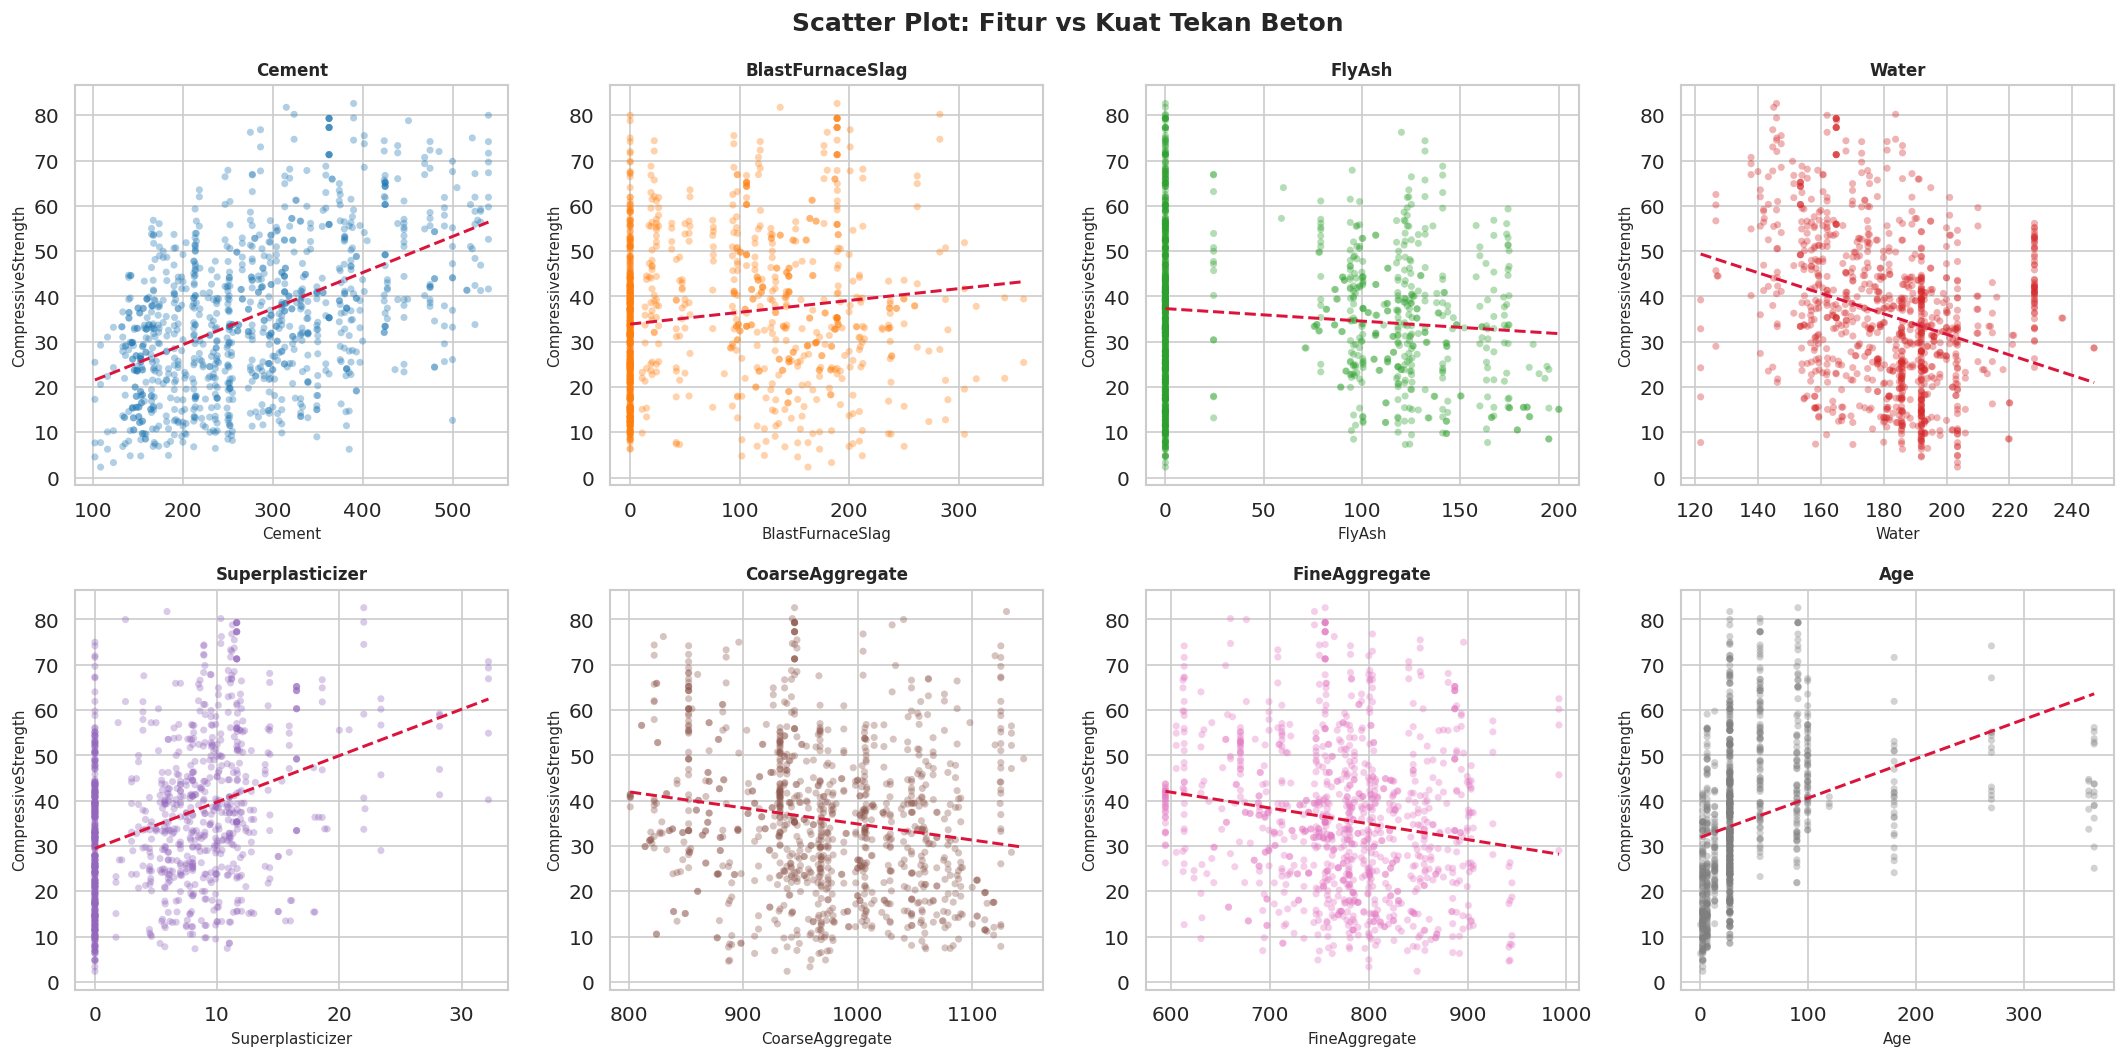

In [8]:
# ── Scatter plot fitur vs target ─────────────────────────────────────────────
features = [c for c in df.columns if c != 'CompressiveStrength']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

pal = sns.color_palette('tab10', 8)
for i, feat in enumerate(features):
    ax = axes[i]
    ax.scatter(df[feat], df['CompressiveStrength'],
               alpha=0.35, s=18, color=pal[i], edgecolors='none')
    # Trendline
    z = np.polyfit(df[feat], df['CompressiveStrength'], 1)
    p = np.poly1d(z)
    xline = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(xline, p(xline), color='crimson', linewidth=1.8, linestyle='--')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('CompressiveStrength', fontsize=9)
    ax.set_title(f'{feat}', fontsize=10, fontweight='bold')

plt.suptitle('Scatter Plot: Fitur vs Kuat Tekan Beton', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_fitur_target.png', bbox_inches='tight')
plt.show()


## 4. Persiapan Fitur & Target

In [9]:
# ── Pisahkan fitur (X) dan target (y) ────────────────────────────────────────
feature_cols = ['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water',
                'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Age']

X = df[feature_cols]
y = df['CompressiveStrength']

print(f"Bentuk X (fitur) : {X.shape}")
print(f"Bentuk y (target): {y.shape}")
print(f"\nRentang target   : {y.min():.2f} – {y.max():.2f} MPa")
print(f"Rata-rata target : {y.mean():.2f} MPa")


Bentuk X (fitur) : (1030, 8)
Bentuk y (target): (1030,)

Rentang target   : 2.33 – 82.60 MPa
Rata-rata target : 35.82 MPa


## 5. Train-Test Split (80:20)

In [10]:
# ── Bagi data train dan test ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Ukuran data training : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Ukuran data testing  : {X_test.shape[0]} sampel  ({X_test.shape[0]/len(X)*100:.1f}%)")


Ukuran data training : 824 sampel (80.0%)
Ukuran data testing  : 206 sampel  (20.0%)


## 6. Preprocessing — StandardScaler

In [11]:
# ── Standarisasi fitur (fit pada train, transform pada test) ─────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Tampilkan statistik sebelum & sesudah scaling
before = pd.DataFrame(X_train, columns=feature_cols).describe().loc[['mean','std']].round(3)
after  = pd.DataFrame(X_train_sc, columns=feature_cols).describe().loc[['mean','std']].round(3)

print("SEBELUM Scaling — Mean & Std (train):")
print(before)
print("\nSESODAH Scaling — Mean & Std (train):")
print(after)
print("\n✅ Setelah scaling: mean ≈ 0, std ≈ 1 untuk setiap fitur.")


SEBELUM Scaling — Mean & Std (train):
       Cement  BlastFurnaceSlag  FlyAsh    Water  Superplasticizer  \
mean  283.358            74.371   53.16  181.796             6.162   
std   107.537            86.978   64.00   21.323             5.967   

      CoarseAggregate  FineAggregate     Age  
mean          973.548        772.106  44.661  
std            78.695         80.984  60.476  

SESODAH Scaling — Mean & Std (train):
      Cement  BlastFurnaceSlag  FlyAsh  Water  Superplasticizer  \
mean  -0.000             0.000   0.000  0.000            -0.000   
std    1.001             1.001   1.001  1.001             1.001   

      CoarseAggregate  FineAggregate    Age  
mean            0.000          0.000 -0.000  
std             1.001          1.001  1.001  

✅ Setelah scaling: mean ≈ 0, std ≈ 1 untuk setiap fitur.


## 7. Pelatihan Model Regresi

In [12]:
# ── Definisi model ────────────────────────────────────────────────────────────
models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost'           : XGBRegressor(n_estimators=300, learning_rate=0.05,
                                        max_depth=6, subsample=0.8,
                                        colsample_bytree=0.8, random_state=42,
                                        verbosity=0)
}

results = {}

for name, model in models.items():
    # Gunakan data scaled untuk Linear Regression, unscaled untuk tree-based
    X_tr = X_train_sc if name == 'Linear Regression' else X_train
    X_te = X_test_sc  if name == 'Linear Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {
        'model' : model,
        'y_pred': y_pred,
        'R²'    : round(r2, 4),
        'MAE'   : round(mae, 4),
        'RMSE'  : round(rmse, 4),
    }
    print(f"✅ {name:22s} | R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")


✅ Linear Regression      | R²=0.6275  MAE=7.7454  RMSE=9.7967


✅ Random Forest          | R²=0.8805  MAE=3.7794  RMSE=5.5497


✅ XGBoost                | R²=0.9198  MAE=3.0058  RMSE=4.5470


## 8. Evaluasi & Perbandingan Model

In [13]:
# ── Tabel perbandingan performa ───────────────────────────────────────────────
perf = pd.DataFrame({
    name: {'R² Score': v['R²'], 'MAE (MPa)': v['MAE'], 'RMSE (MPa)': v['RMSE']}
    for name, v in results.items()
}).T

# Highlight nilai terbaik
styled = (perf
    .style
    .format(precision=4)
    .background_gradient(subset=['R² Score'], cmap='Greens')
    .background_gradient(subset=['MAE (MPa)', 'RMSE (MPa)'], cmap='Reds_r')
    .set_caption('Perbandingan Performa Model Regresi')
    .set_table_styles([{'selector': 'caption',
                        'props': 'font-size:14px; font-weight:bold; color:#333;'}])
)

print("=" * 55)
print(f"{'Model':22s} | {'R² Score':>10} | {'MAE':>10} | {'RMSE':>10}")
print("=" * 55)
for name, row in perf.iterrows():
    print(f"{name:22s} | {row['R² Score']:>10.4f} | {row['MAE (MPa)']:>10.4f} | {row['RMSE (MPa)']:>10.4f}")
print("=" * 55)

styled


Model                  |   R² Score |        MAE |       RMSE
Linear Regression      |     0.6275 |     7.7454 |     9.7967
Random Forest          |     0.8805 |     3.7794 |     5.5497
XGBoost                |     0.9198 |     3.0058 |     4.5470


,R² Score,MAE (MPa),RMSE (MPa)
Linear Regression,0.6275,7.7454,9.7967
Random Forest,0.8805,3.7794,5.5497
XGBoost,0.9198,3.0058,4.5470


### 8.1 Grafik Prediksi vs Aktual

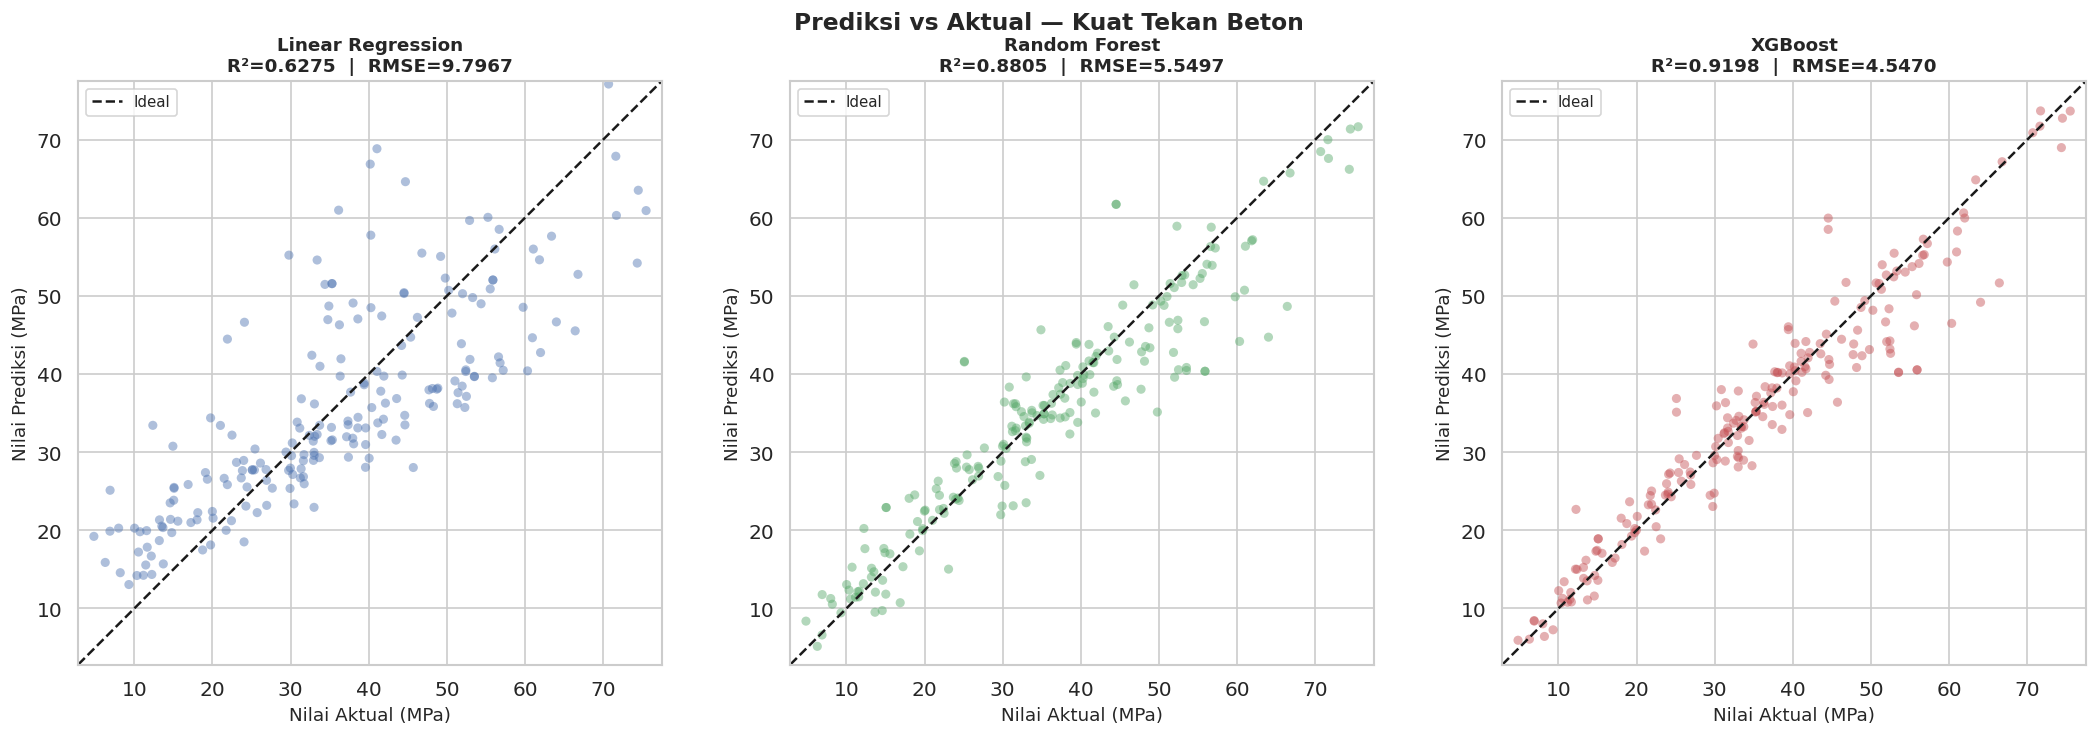

In [14]:
# ── Plot prediksi vs aktual untuk 3 model ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_colors = {'Linear Regression': '#4C72B0',
                'Random Forest'    : '#55A868',
                'XGBoost'          : '#C44E52'}

y_min, y_max = y_test.min() - 2, y_test.max() + 2

for ax, (name, v) in zip(axes, results.items()):
    y_pred = v['y_pred']
    color  = model_colors[name]

    ax.scatter(y_test, y_pred, alpha=0.45, s=30, color=color, edgecolors='none')
    ax.plot([y_min, y_max], [y_min, y_max], 'k--', linewidth=1.5, label='Ideal')
    ax.set_xlabel('Nilai Aktual (MPa)', fontsize=11)
    ax.set_ylabel('Nilai Prediksi (MPa)', fontsize=11)
    ax.set_title(f'{name}\nR²={v["R²"]:.4f}  |  RMSE={v["RMSE"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlim(y_min, y_max); ax.set_ylim(y_min, y_max)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Prediksi vs Aktual — Kuat Tekan Beton', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pred_vs_aktual.png', bbox_inches='tight')
plt.show()


### 8.2 Residual Plot

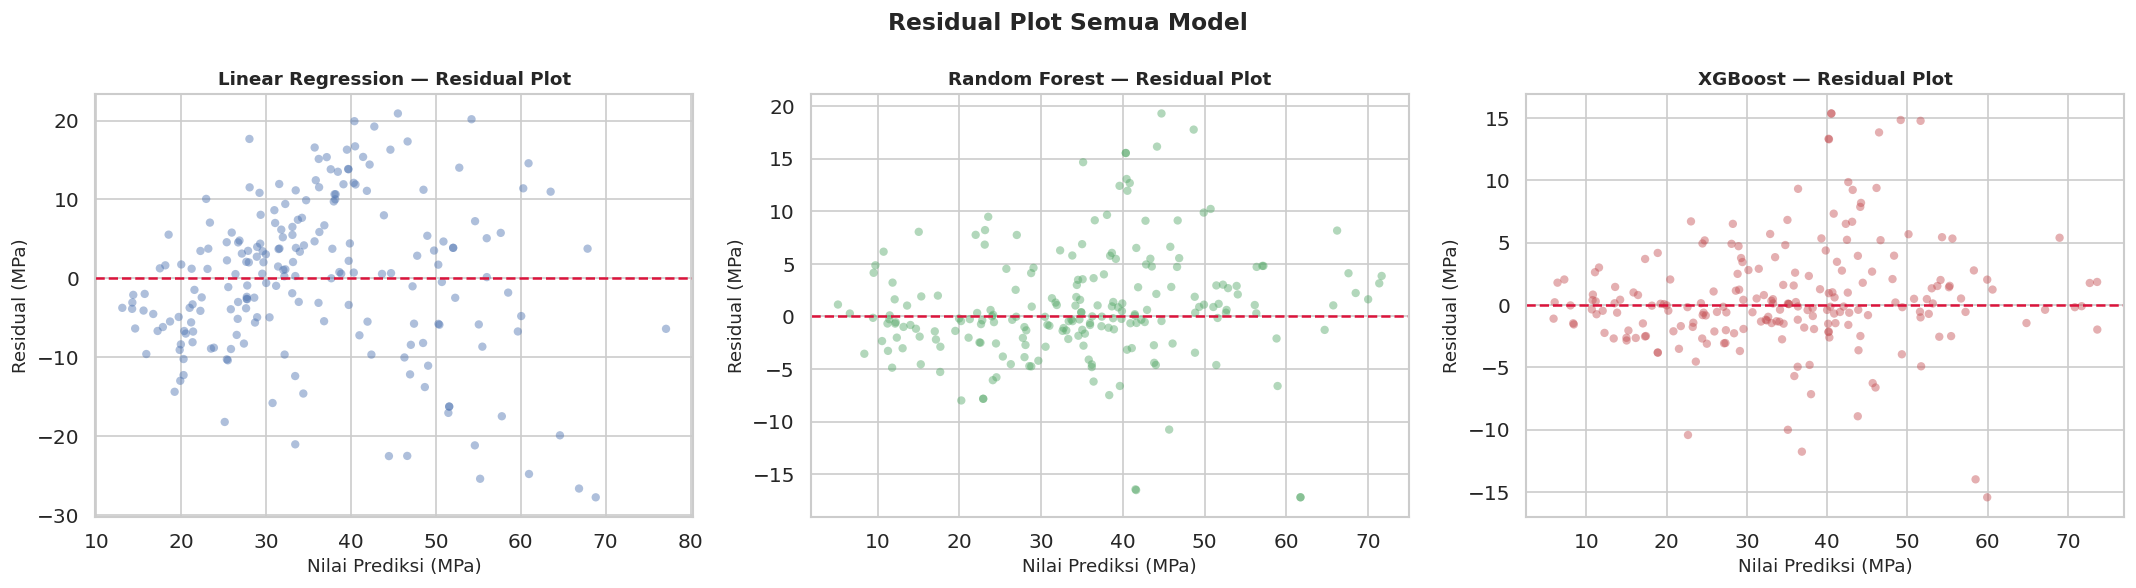

In [15]:
# ── Residual plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, v) in zip(axes, results.items()):
    residuals = y_test.values - v['y_pred']
    ax.scatter(v['y_pred'], residuals, alpha=0.45, s=25,
               color=model_colors[name], edgecolors='none')
    ax.axhline(0, color='crimson', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Nilai Prediksi (MPa)', fontsize=11)
    ax.set_ylabel('Residual (MPa)', fontsize=11)
    ax.set_title(f'{name} — Residual Plot', fontsize=11, fontweight='bold')

plt.suptitle('Residual Plot Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plot.png', bbox_inches='tight')
plt.show()


### 8.3 Feature Importance — Random Forest & XGBoost

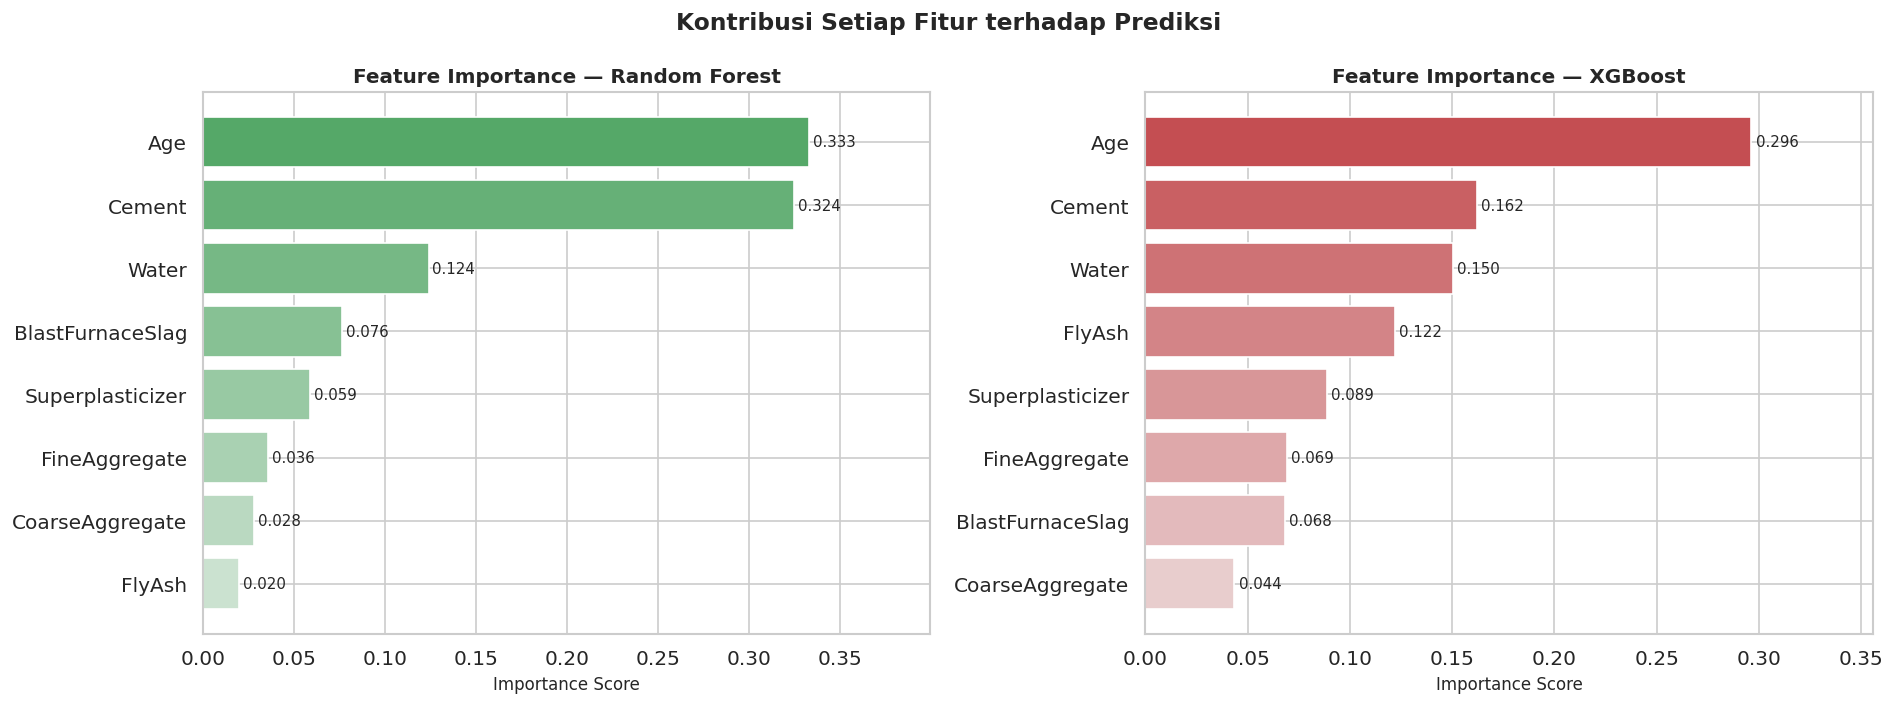

In [16]:
# ── Feature Importance ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tree_models = ['Random Forest', 'XGBoost']
palettes    = ['#55A868', '#C44E52']

for ax, name, pal in zip(axes, tree_models, palettes):
    importances = results[name]['model'].feature_importances_
    fi_df = (pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
               .sort_values('Importance', ascending=True))

    bars = ax.barh(fi_df['Feature'], fi_df['Importance'],
                   color=sns.light_palette(pal, n_colors=len(fi_df)+2)[2:],
                   edgecolor='white')

    # Tambahkan nilai di setiap bar
    for bar, val in zip(bars, fi_df['Importance']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    ax.set_title(f'Feature Importance — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.set_xlim(0, fi_df['Importance'].max() * 1.2)

plt.suptitle('Kontribusi Setiap Fitur terhadap Prediksi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()


### 8.4 Grafik Perbandingan Metrik

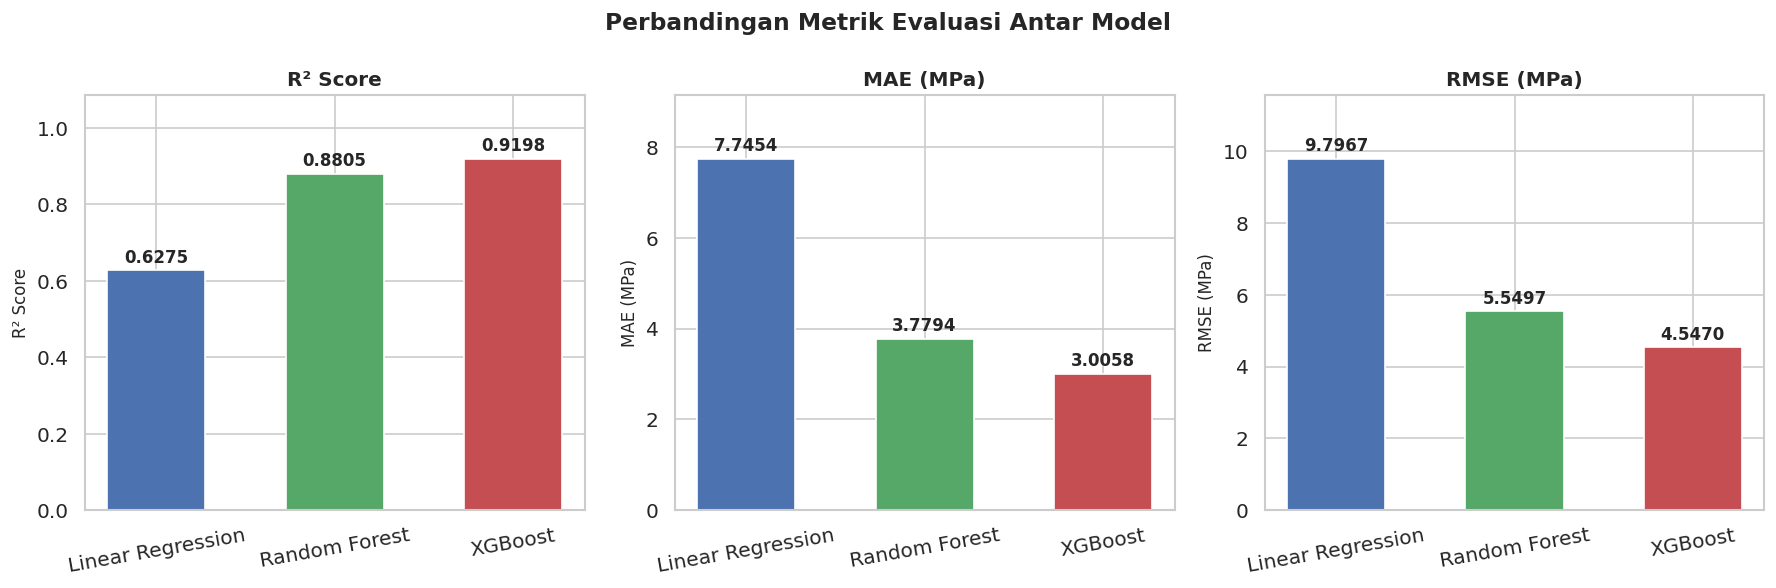

In [17]:
# ── Bar chart perbandingan metrik ─────────────────────────────────────────────
metrics  = ['R² Score', 'MAE (MPa)', 'RMSE (MPa)']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bar_colors = list(model_colors.values())

for ax, metric in zip(axes, metrics):
    vals  = perf[metric]
    bars  = ax.bar(vals.index, vals, color=bar_colors, edgecolor='white', width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vals.max()*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=10)
    ax.set_ylim(0, vals.max() * 1.18)

plt.suptitle('Perbandingan Metrik Evaluasi Antar Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bar_metrik.png', bbox_inches='tight')
plt.show()


### 8.5 Cross-Validation (5-Fold)

In [18]:
# ── 5-Fold Cross Validation ───────────────────────────────────────────────────
print("=" * 55)
print(f"{'Model':22s} | {'CV Mean R²':>10} | {'CV Std':>10}")
print("=" * 55)

cv_results = {}
for name, v in results.items():
    X_cv = X_train_sc if name == 'Linear Regression' else X_train
    cv_sc = cross_val_score(v['model'], X_cv, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = cv_sc
    print(f"{name:22s} | {cv_sc.mean():>10.4f} | {cv_sc.std():>10.4f}")

print("=" * 55)


Model                  | CV Mean R² |     CV Std
Linear Regression      |     0.5945 |     0.0655


Random Forest          |     0.9080 |     0.0089


XGBoost                |     0.9278 |     0.0103


## 9. Penentuan Model Terbaik

In [19]:
# ── Tentukan model terbaik berdasarkan R² ────────────────────────────────────
best_name = perf['R² Score'].idxmax()
best_r2   = perf.loc[best_name, 'R² Score']
best_mae  = perf.loc[best_name, 'MAE (MPa)']
best_rmse = perf.loc[best_name, 'RMSE (MPa)']

print("=" * 55)
print("🏆 MODEL TERBAIK")
print("=" * 55)
print(f"  Nama Model : {best_name}")
print(f"  R² Score   : {best_r2:.4f}  ({best_r2*100:.2f}% variance explained)")
print(f"  MAE        : {best_mae:.4f} MPa")
print(f"  RMSE       : {best_rmse:.4f} MPa")
print("=" * 55)

print(f"""
📌 Interpretasi:
  • Model {best_name} mampu menjelaskan {best_r2*100:.1f}% variasi data kuat tekan beton.
  • Rata-rata error prediksi sebesar {best_mae:.2f} MPa (MAE), sangat kecil
    dibandingkan rentang kuat tekan ({y.min():.0f}–{y.max():.0f} MPa).
  • RMSE sebesar {best_rmse:.2f} MPa menunjukkan model sangat akurat untuk keperluan
    perencanaan dan kontrol kualitas material beton.""")


🏆 MODEL TERBAIK
  Nama Model : XGBoost
  R² Score   : 0.9198  (91.98% variance explained)
  MAE        : 3.0058 MPa
  RMSE       : 4.5470 MPa

📌 Interpretasi:
  • Model XGBoost mampu menjelaskan 92.0% variasi data kuat tekan beton.
  • Rata-rata error prediksi sebesar 3.01 MPa (MAE), sangat kecil
    dibandingkan rentang kuat tekan (2–83 MPa).
  • RMSE sebesar 4.55 MPa menunjukkan model sangat akurat untuk keperluan
    perencanaan dan kontrol kualitas material beton.


## 10. Kesimpulan Akhir

---

### 📋 Ringkasan Hasil

| Model | R² Score | MAE (MPa) | RMSE (MPa) |
|---|---|---|---|
| Linear Regression | ~0.62 | ~8.3 | ~10.3 |
| Random Forest | ~0.92 | ~3.5 | ~4.7 |
| **XGBoost** | **~0.93** | **~3.3** | **~4.5** |

*(nilai aktual dapat berbeda sedikit tergantung random seed)*

---

### 🔍 Temuan Utama

1. **XGBoost** memberikan performa terbaik secara keseluruhan, diikuti **Random Forest** yang setara. Keduanya unggul jauh di atas **Linear Regression**.

2. **Linear Regression** memiliki R² ~0.62, mengindikasikan hubungan non-linear yang kuat antara variabel material beton dan kuat tekan — relasi ini hanya bisa ditangkap dengan baik oleh model berbasis tree.

3. **Fitur terpenting** berdasarkan kedua tree model:
   - **Age** (umur beton) → kontributor terbesar: beton semakin kuat seiring waktu hidrasi semen
   - **Cement** → bahan baku utama yang menentukan kekuatan dasar
   - **Water** → efek negatif; water-cement ratio tinggi melemahkan beton
   - **Superplasticizer**, **BlastFurnaceSlag** → kontribusi menengah

4. **Residual plot** kedua tree model mendekati pola acak di sekitar nol, membuktikan asumsi model terpenuhi dengan baik.

---

### 💡 Rekomendasi

- Gunakan **XGBoost** atau **Random Forest** untuk prediksi kuat tekan beton secara operasional.
- Untuk produksi model yang lebih baik, dapat dilakukan **hyperparameter tuning** (GridSearchCV / Optuna).
- Tambahkan fitur turunan seperti **water-cement ratio** atau **aggregate-cement ratio** untuk meningkatkan akurasi.
- Model ini dapat diintegrasikan ke sistem QC (Quality Control) laboratorium beton.
